In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from tqdm.notebook import trange # Para una barra de progreso en Colab

# --- 1. Funciones de Activación y sus Derivadas ---
# (Las derivadas reciben la SALIDA de la activación, no la entrada)

def sigmoid(x):
    """Función de activación sigmoidal."""
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def sigmoid_derivative(a):
    """Derivada de la sigmoidal (recibe la activación 'a')."""
    return a * (1 - a)

def linear(x):
    """Función de activación lineal."""
    return x

def linear_derivative(a):
    """Derivada de la lineal (es constante 1)."""
    return 1

# --- 2. Clase de la Red Neuronal (MLP) ---

class MLP:
    """
    Implementación de una Red Neuronal Multicapa (MLP) desde cero.

    Argumentos:
    - architecture (list): Lista de enteros que define la arquitectura.
        Ej: [100, 10, 3] -> 100 entradas, 1 capa oculta de 10 neuronas, 3 salidas.
        Ej: [100, 10, 5, 3] -> 100 entradas, 2 capas ocultas (10 y 5), 3 salidas.

    - activations (list): Lista de funciones de activación para cada capa
        (excepto la de entrada). Su longitud debe ser len(architecture) - 1.

    - derivatives (list): Lista de funciones derivadas para cada capa.
    """

    def __init__(self, architecture, activations, derivatives):

        self.architecture = architecture
        self.activations = activations
        self.derivatives = derivatives

        # --- Inicialización de Pesos y Sesgos ---
        # Inicializamos los pesos con valores aleatorios pequeños (Xavier/Glorot)
        # y los sesgos (biases) en cero.
        self.weights = []
        self.biases = []

        # --- Almacenamiento para el Término Momento ---
        self.prev_weight_updates = []
        self.prev_bias_updates = []

        # Iteramos desde la capa 0 (entrada) hasta la penúltima
        for i in range(len(architecture) - 1):
            # Pesos W[i] conectan capa i con capa i+1
            # Usamos inicialización 'Xavier' para ayudar a la convergencia
            limit = np.sqrt(6 / (architecture[i] + architecture[i+1]))
            w = np.random.uniform(-limit, limit, (architecture[i], architecture[i+1]))

            # Sesgos b[i] son para la capa i+1
            b = np.zeros((1, architecture[i+1]))

            self.weights.append(w)
            self.biases.append(b)

            # Inicializar almacen de momento con ceros
            self.prev_weight_updates.append(np.zeros_like(w))
            self.prev_bias_updates.append(np.zeros_like(b))

    def _forward_propagation(self, x):
        """
        Pasa una *única muestra* 'x' a través de la red.
        Devuelve todas las activaciones y las sumas ponderadas (z).
        """
        # 'a' es la activación de la capa actual
        a = x.reshape(1, -1) # Asegurar que 'x' sea un vector fila

        activations = [a] # Lista para guardar todas las activaciones (incluye entrada)
        zs = []           # Lista para guardar las sumas ponderadas (pre-activación)

        # Iterar a través de cada capa
        for i in range(len(self.weights)):
            # 1. Calcular suma ponderada: z = (a_prev * W) + b
            z = np.dot(a, self.weights[i]) + self.biases[i]

            # 2. Aplicar función de activación: a = g(z)
            a = self.activations[i](z)

            # Guardar resultados
            zs.append(z)
            activations.append(a)

        return activations, zs

    def _backward_propagation(self, y_true, activations, zs):
        """
        Realiza la retropropagación del error para *una única muestra*.
        Calcula los gradientes (nabla_w, nabla_b) para pesos y sesgos.
        """

        # 1. Inicializar gradientes (listas de matrices de ceros)
        nabla_w = [np.zeros_like(w) for w in self.weights]
        nabla_b = [np.zeros_like(b) for b in self.biases]

        # 2. Calcular el error (delta) en la capa de SALIDA (L)
        # delta = (a_L - y) * g'(z_L)
        # (a_L - y) es el error MSE
        # g'(z_L) es la derivada de la activación de salida

        # 'activations[-1]' es la salida de la red (a_L)
        # 'self.derivatives[-1]' es la función de derivada de la capa de salida
        delta = (activations[-1] - y_true) * self.derivatives[-1](activations[-1])

        # 3. Asignar gradientes para la capa de SALIDA
        nabla_b[-1] = delta
        # np.outer crea la matriz de gradiente (activación_previa .T * delta)
        nabla_w[-1] = np.outer(activations[-2], delta)

        # 4. Propagar el error hacia atrás
        # Iterar desde la penúltima capa (l = L-1) hasta el principio
        for l in range(2, len(self.architecture)):
            # '-l' nos permite movernos hacia atrás: -2, -3, ...

            # delta_l = (delta_l+1 * W_l+1.T) * g'(z_l)
            delta = np.dot(delta, self.weights[-l+1].T) * \
                    self.derivatives[-l](activations[-l])

            # 5. Asignar gradientes para la capa OCULTA actual
            nabla_b[-l] = delta
            nabla_w[-l] = np.outer(activations[-l-1], delta)

        return nabla_w, nabla_b

    def _update_weights(self, nabla_w, nabla_b, learning_rate, momentum):
        """
        Actualiza los pesos y sesgos usando los gradientes calculados
        y aplicando el término momento.
        """

        for i in range(len(self.weights)):

            # --- Cálculo de la actualización con Momento ---
            # update = (momentum * prev_update) + (learning_rate * gradiente)

            weight_update = (momentum * self.prev_weight_updates[i]) + \
                            (learning_rate * nabla_w[i])

            bias_update = (momentum * self.prev_bias_updates[i]) + \
                          (learning_rate * nabla_b[i])

            # --- Aplicar la actualización ---
            self.weights[i] -= weight_update
            self.biases[i] -= bias_update

            # --- Guardar la actualización actual para la próxima iteración ---
            self.prev_weight_updates[i] = weight_update
            self.prev_bias_updates[i] = bias_update

    def fit(self, X_train, y_train, X_val, y_val, epochs, learning_rate, momentum):
      """
      Entrena la red (con barra de progreso TQDM y detección de NAN/Overflow).
      """
      history = {'train_mse': [], 'val_mse': []}

      # --- Barra de progreso ---
      try:
          epoch_iterator = trange(epochs, desc="Entrenando Épocas", leave=False)
      except Exception:
          epoch_iterator = range(epochs)

      final_train_mse = np.nan
      final_val_mse = np.nan

      for epoch in epoch_iterator:

          # --- (código de entrenamiento SGD) ---
          indices = np.arange(X_train.shape[0])
          np.random.shuffle(indices)
          X_train_shuffled = X_train[indices]
          y_train_shuffled = y_train[indices]

          for x, y in zip(X_train_shuffled, y_train_shuffled):
              activations, zs = self._forward_propagation(x)
              nabla_w, nabla_b = self._backward_propagation(y, activations, zs)
              self._update_weights(nabla_w, nabla_b, learning_rate, momentum)

          # --- (código de Evaluación) ---
          train_preds = self.predict(X_train, batch_mode=True)
          final_train_mse = np.mean((train_preds - y_train)**2)

          # --- (código de Detección de Overflow) ---
          if np.isnan(final_train_mse) or np.isinf(final_train_mse):
              remaining_epochs = epochs - (epoch + 1)
              history['train_mse'].append(np.inf)
              history['val_mse'].append(np.inf)
              if remaining_epochs > 0:
                  history['train_mse'].extend([np.inf] * remaining_epochs)
                  history['val_mse'].extend([np.inf] * remaining_epochs)
              final_train_mse = np.inf # Asegurar que el reporte final sea 'inf'
              final_val_mse = np.inf
              break # Salir del bucle

          history['train_mse'].append(final_train_mse)

          val_preds = self.predict(X_val, batch_mode=True)
          final_val_mse = np.mean((val_preds - y_val)**2)
          history['val_mse'].append(final_val_mse)

          if np.isnan(final_val_mse) or np.isinf(final_val_mse):
              remaining_epochs = epochs - (epoch + 1)
              if remaining_epochs > 0:
                  history['train_mse'].extend([np.inf] * remaining_epochs)
                  history['val_mse'].extend([np.inf] * remaining_epochs)
              final_val_mse = np.inf
              break

          # Actualizar la barra con el MSE en vivo ---
          if hasattr(epoch_iterator, 'set_postfix'):
              epoch_iterator.set_postfix(
                  train_mse=f"{final_train_mse:.5f}",
                  val_mse=f"{final_val_mse:.5f}"
              )

      # Asegurar que las listas tengan la longitud correcta si se detuvo
      while len(history['train_mse']) < epochs:
          history['train_mse'].append(final_train_mse)
          history['val_mse'].append(final_val_mse)

      # Cerrar la barra de TQDM
      if hasattr(epoch_iterator, 'close'):
          epoch_iterator.close()

      return history

    def predict(self, X, batch_mode=False):
        """
        Realiza predicciones para un conjunto de datos X.

        - Si batch_mode es True, X se asume como (n_muestras, n_features)
        - Si batch_mode es False, itera sobre cada muestra (más lento)
        """

        if batch_mode:
            a = X
            for i in range(len(self.weights)):
                z = np.dot(a, self.weights[i]) + self.biases[i]
                a = self.activations[i](z)
            return a

        else:
            predictions = []
            for x in X:
                a, _ = self._forward_propagation(x)
                predictions.append(a[-1].flatten()) # a[-1] es la salida
            return np.array(predictions)

# --- 3. Funciones Auxiliares (Carga de Datos y Gráficos) ---

def load_dataset(path):
    """Carga un dataset desde un CSV y lo separa en X e y."""
    try:
        df = pd.read_csv(path)
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo en {path}")
        print("Asegúrate de haber montado Google Drive y que la ruta sea correcta.")
        return None, None

    # Asumimos que las columnas 'p0' a 'p99' son features
    feature_cols = [f'p{i}' for i in range(100)]
    X = df[feature_cols].values

    # La columna 'letra' es el target
    y = df['letra'].values.reshape(-1, 1) # Asegurar que sea (n, 1)

    return X, y

def plot_error_history(history, title="Curva de Aprendizaje"):
    """
    Grafica el MSE de entrenamiento y validación.
    (Añadido un parámetro 'title')
    """
    plt.figure(figsize=(10, 6))
    plt.plot(history['train_mse'], label='Error de Entrenamiento (MSE)', color='blue')
    plt.plot(history['val_mse'], label='Error de Validación (MSE)', color='orange', linestyle='--')
    plt.title(title, fontsize=16) # Usa el título dinámico
    plt.xlabel('Época')
    plt.ylabel('Mean Squared Error (MSE)')
    plt.legend()
    plt.grid(True)
    plt.ylim(bottom=0)
    plt.show() # Muestra el gráfico

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cargando datasets...
Datos de entrenamiento cargados: 400 muestras
Datos de validación cargados: 100 muestras

Ejemplo de One-Hot Encoding:
d -> [0. 1. 0.]
d -> [0. 1. 0.]


Entrenando Épocas:   0%|          | 0/300 [00:00<?, ?it/s]

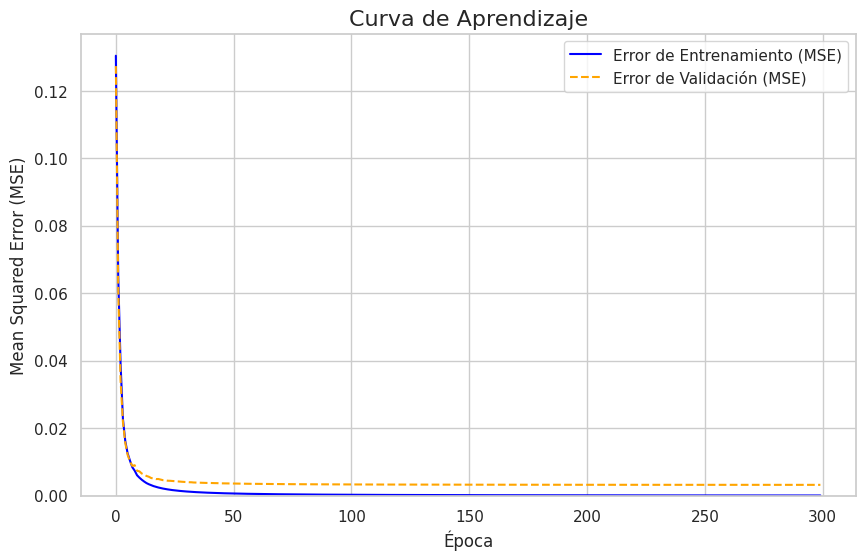


--- Prueba de Predicción ---
Patrón: Muestra #0
Etiqueta Real:   'd'  [0. 1. 0.]
Predicción (raw): [0.0036 0.9972 0.0017]
Predicción (letra): 'd'


In [ ]:
# --- 4. Bloque Principal de Ejecución ---

# --- A. Montar Google Drive---
from google.colab import drive
drive.mount('/content/drive')

# --- B. Configuración del Experimento ---

# Rutas
BASE_PATH = "/content/drive/My Drive/TP_IA_2025/datasets"
# Usaremos el dataset 500 con split 80/20 como ejemplo
TRAIN_PATH = f"{BASE_PATH}/dataset_500/train80_val20/train.csv"
VAL_PATH = f"{BASE_PATH}/dataset_500/train80_val20/val.csv"

# Hiperparámetros de la Red
# 1 capa oculta de 10 neuronas
ARCHITECTURE = [100, 10, 3]
# Sigmoid en capa oculta, Sigmoid en capa de salida
ACTIVATIONS = [sigmoid, sigmoid]
DERIVATIVES = [sigmoid_derivative, sigmoid_derivative]

# Hiperparámetros de Entrenamiento
EPOCHS = 300           # El TP pide muchas simulaciones, 300-500 es un buen inicio
LEARNING_RATE = 0.01   # Tasa de aprendizaje
MOMENTUM = 0.9         # Término momento (común usar 0.9)


# --- C. Carga y Preparación de Datos ---
print("Cargando datasets...")
X_train, y_train_labels = load_dataset(TRAIN_PATH)
X_val, y_val_labels = load_dataset(VAL_PATH)

if X_train is not None:
    print(f"Datos de entrenamiento cargados: {X_train.shape[0]} muestras")
    print(f"Datos de validación cargados: {X_val.shape[0]} muestras")

    # --- D. One-Hot Encoding de Etiquetas ---
    # Convertir 'b', 'd', 'f' en [1,0,0], [0,1,0], [0,0,1]
    # 'categories' asegura que el orden sea siempre 'b', 'd', 'f'
    encoder = OneHotEncoder(sparse_output=False, categories=[['b', 'd', 'f']])

    y_train_oh = encoder.fit_transform(y_train_labels)
    y_val_oh = encoder.transform(y_val_labels)

    print("\nEjemplo de One-Hot Encoding:")
    print(f"{y_train_labels[0][0]} -> {y_train_oh[0]}")
    print(f"{y_train_labels[1][0]} -> {y_train_oh[1]}")

    # --- E. Inicializar y Entrenar la Red ---

    # Crear la instancia de la red
    mlp = MLP(architecture=ARCHITECTURE,
              activations=ACTIVATIONS,
              derivatives=DERIVATIVES)

    # Entrenar
    history = mlp.fit(X_train, y_train_oh,
                      X_val, y_val_oh,
                      epochs=EPOCHS,
                      learning_rate=LEARNING_RATE,
                      momentum=MOMENTUM)

    # --- F. Visualizar Resultados ---
    plot_error_history(history)

    # --- G. Probar una Predicción ---
    print("\n--- Prueba de Predicción ---")

    # Tomar la primera muestra de validación
    sample_index = 0
    sample_x = X_val[sample_index]
    sample_y_true_label = y_val_labels[sample_index][0]
    sample_y_true_oh = y_val_oh[sample_index]

    # Predecir
    prediction_raw = mlp.predict(sample_x.reshape(1, -1))

    # Interpretar resultados
    # np.argmax nos da el índice del valor más alto
    predicted_index = np.argmax(prediction_raw)
    predicted_letter = encoder.categories_[0][predicted_index]

    print(f"Patrón: Muestra #{sample_index}")
    print(f"Etiqueta Real:   '{sample_y_true_label}'  {sample_y_true_oh}")
    print(f"Predicción (raw): {prediction_raw.flatten().round(4)}")
    print(f"Predicción (letra): '{predicted_letter}'")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Interfaz

In [ ]:
# --- PASO 1: Instalación ---
!pip install -q anywidget

In [ ]:
# --- PASO 2: Importaciones ---
import anywidget
import traitlets
import ipywidgets as widgets
import numpy as np
import random
from IPython.display import display

# --- PASO 3: Definición de los patrones de letras ---

BASE_B = np.array([
    0,0,0,0,0,0,0,0,0,0,
    0,0,1,0,0,0,0,0,0,0,
    0,0,1,0,0,0,0,0,0,0,
    0,0,1,0,0,0,0,0,0,0,
    0,0,1,1,1,1,1,0,0,0,
    0,0,1,0,0,0,0,1,0,0,
    0,0,1,0,0,0,0,1,0,0,
    0,0,1,0,0,0,0,1,0,0,
    0,0,1,1,1,1,1,0,0,0,
    0,0,0,0,0,0,0,0,0,0
])

BASE_D = np.array([
    0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,1,0,0,
    0,0,0,0,0,0,0,1,0,0,
    0,0,0,0,0,0,0,1,0,0,
    0,0,0,1,1,1,1,1,0,0,
    0,0,1,0,0,0,0,1,0,0,
    0,0,1,0,0,0,0,1,0,0,
    0,0,1,0,0,0,0,1,0,0,
    0,0,0,1,1,1,1,1,0,0,
    0,0,0,0,0,0,0,0,0,0
])

BASE_F = np.array([
    0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,1,1,0,0,0,
    0,0,0,0,1,0,0,1,0,0,
    0,0,0,0,1,0,0,0,0,0,
    0,0,1,1,1,1,1,0,0,0,
    0,0,0,0,1,0,0,0,0,0,
    0,0,0,0,1,0,0,0,0,0,
    0,0,0,0,1,0,0,0,0,0,
    0,0,0,0,1,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0
])

# Convertir los arrays de NumPy a listas de Python para el widget
pattern_b = list(BASE_B)
pattern_d = list(BASE_D)
pattern_f = list(BASE_F)
pattern_clear = [0] * 100


# --- PASO 4: Definición del Widget de la Cuadrícula (con CSS mejorado) ---

class PatternGridWidget(anywidget.AnyWidget):
    """
    Un widget de cuadrícula 10x10 'pintable' con estilos mejorados.
    """

    # --- (NUEVO) CSS Mejorado ---
    _css = """
    .grid-container {
        display: grid;
        grid-template-columns: repeat(10, 25px);
        grid-template-rows: repeat(10, 25px);
        border: 1px solid #aaa;
        width: 252px;
        height: 252px;
        background-color: #fdfdfd;
        cursor: pointer;

        /* Estilos nuevos */
        border-radius: 4px; /* Esquinas redondeadas */
        box-shadow: 0 4px 8px rgba(0,0,0,0.1); /* Sombra suave */
        overflow: hidden; /* Asegura que las celdas respeten el borde redondeado */
        margin-top: 10px;
    }
    .grid-cell {
        width: 25px;
        height: 25px;
        box-sizing: border-box;
        border: 1px solid #eee; /* Bordes de celda más claros */

        /* (NUEVO) Transición suave al pintar */
        transition: background-color 0.15s ease-in-out;
    }

    /* (NUEVO) Efecto Hover: se resalta la celda antes de hacer clic */
    .grid-cell:not(.painted):hover {
        background-color: #e0e0e0;
    }

    .grid-cell.painted {
        background-color: #333; /* Color de celda "pintada" */
        border-color: #222; /* Borde más oscuro para celdas pintadas */
    }
    """

    # --- JavaScript (Sin cambios) ---
    _esm = """
    export function render(view) {
        let model = view.model;
        let container = document.createElement("div");
        container.classList.add("grid-container");
        let cells = [];

        for (let i = 0; i < 100; i++) {
            let cell = document.createElement("div");
            cell.classList.add("grid-cell");
            cell.dataset.index = i;
            cell.addEventListener("click", () => {
                let currentState = model.get("grid_state").slice();
                currentState[i] = currentState[i] === 1 ? 0 : 1;
                model.set("grid_state", currentState);
                model.save_changes();
            });
            container.appendChild(cell);
            cells.push(cell);
        }

        function updateGridFromModel() {
            let state = model.get("grid_state");
            if (state.length !== 100) return;
            for (let i = 0; i < 100; i++) {
                if (state[i] === 1) {
                    cells[i].classList.add("painted");
                } else {
                    cells[i].classList.remove("painted");
                }
            }
        }
        model.on("change:grid_state", updateGridFromModel);
        updateGridFromModel();
        view.el.appendChild(container);
    }
    """

    # --- Python (Sin cambios) ---
    grid_state = traitlets.List([0] * 100, minlen=100, maxlen=100).tag(sync=True)


# --- PASO 5: Interfaz de Python (Botones y Lógica) ---

app_state = {
    'base_pattern': pattern_clear.copy()
}

# --- Instanciar el widget ---
grid_widget = PatternGridWidget()

# --- Definir Layouts Comunes ---
# Layout para botones: crecerán para llenar el espacio (flex)
button_layout = widgets.Layout(flex='1 1 auto', margin='2px')

# Layout para el slider: ocupará más espacio que el botón
slider_layout = widgets.Layout(flex='3 1 auto', margin='2px')

# --- Crear los Botones y Sliders (con layouts) ---
btn_b = widgets.Button(description="Letra 'b'", button_style='primary', layout=button_layout)
btn_d = widgets.Button(description="Letra 'd'", button_style='primary', layout=button_layout)
btn_f = widgets.Button(description="Letra 'f'", button_style='primary', layout=button_layout)

slider_distort = widgets.IntSlider(
    value=10, min=1, max=30, step=1,
    description='Distorsión (%):',
    style={'description_width': 'initial'},
    layout=slider_layout
)
btn_apply_distort = widgets.Button(description="Aplicar", button_style='warning', icon='random', layout=button_layout)
btn_predict = widgets.Button(description="Predecir", button_style='success', layout=button_layout)
btn_clear = widgets.Button(description="Limpiar", icon='trash', layout=button_layout)

# --- Área de Salida ---
output_area = widgets.Output()

# --- Lógica de los Botones (Exactamente igual que antes) ---

def set_pattern(pattern_list):
    def handler(b):
        app_state['base_pattern'] = pattern_list.copy()
        grid_widget.grid_state = pattern_list
    return handler

btn_b.on_click(set_pattern(pattern_b))
btn_d.on_click(set_pattern(pattern_d))
btn_f.on_click(set_pattern(pattern_f))
btn_clear.on_click(set_pattern(pattern_clear))

def on_grid_change(change):
    app_state['base_pattern'] = change['new']
grid_widget.observe(on_grid_change, names='grid_state')

def on_apply_distort_click(b):
    grid_widget.unobserve(on_grid_change, names='grid_state')
    current_state = list(app_state['base_pattern'])
    distortion_percentage = slider_distort.value
    num_to_flip = distortion_percentage

    if num_to_flip > 0:
        indices_to_flip = random.sample(range(100), num_to_flip)
    else:
        indices_to_flip = []

    for i in indices_to_flip:
        current_state[i] = 1 - current_state[i]
    grid_widget.grid_state = current_state
    grid_widget.observe(on_grid_change, names='grid_state')

btn_apply_distort.on_click(on_apply_distort_click)

def on_predict_click(b):
    """
    Toma el estado actual de la cuadrícula, lo pasa al modelo MLP
    entrenado y muestra la predicción.
    """

    # 1. Obtener el vector de la cuadrícula
    vector_list = grid_widget.grid_state

    # 2. Convertir a formato NumPy (1, 100) para el modelo
    vector_np = np.array(vector_list).reshape(1, 100)

    # 3. Limpiar la salida anterior
    with output_area:
        output_area.clear_output()

        try:
            # 4. Verificar que el modelo 'mlp' y 'encoder' existan
            #    (Deben haber sido definidos y entrenados en una celda anterior)
            if 'mlp' not in globals() or 'encoder' not in globals():
                print("Error: El modelo 'mlp' o el 'encoder' no están definidos.")
                print("Asegúrate de haber ejecutado la celda de entrenamiento.")
                return

            # 5. Realizar la predicción
            # Usamos batch_mode=True, es eficiente incluso para una muestra
            pred_raw = mlp.predict(vector_np, batch_mode=True)

            # 6. Interpretar los resultados
            pred_prob = pred_raw.flatten() # Convertir de [[...]] a [...]
            predicted_index = np.argmax(pred_prob)
            predicted_letter = encoder.categories_[0][predicted_index]

            # 7. Mostrar la predicción de forma clara
            print("--- 🤖 Resultado de la Predicción ---")
            print(f"\nLetra Predicha: '{predicted_letter}'")
            print("\n--- Confianza del Modelo ---")

            # Imprimir las "confianzas" para cada letra
            for i, letra in enumerate(encoder.categories_[0]):
                prob_percent = pred_prob[i] * 100
                print(f" '{letra}': {prob_percent:.2f}%")

        except Exception as e:
            print(f"Ocurrió un error inesperado durante la predicción:")
            print(f"Detalle: {e}")
            print(f"Asegúrate de que 'mlp' y 'encoder' estén definidos.")

btn_predict.on_click(on_predict_click)


# --- PASO 6: Mostrar la Interfaz Completa (Con Layout de Contenedor) ---

# Título con mejor estilo
title_widget = widgets.HTML(
    value="<h2 style='font-family: Arial, sans-serif; margin-bottom: 0px;'>🎨 Editor de Patrones 10x10</h2>"
)

# Layout para centrar la cuadrícula
grid_layout = widgets.HBox(
    [grid_widget],
    layout=widgets.Layout(justify_content='center', padding='10px 0')
)

# HBoxes con ancho completo
letter_buttons = widgets.HBox(
    [btn_b, btn_d, btn_f],
    layout=widgets.Layout(width='100%')
)
distort_controls = widgets.HBox(
    [slider_distort, btn_apply_distort],
    layout=widgets.Layout(width='100%', align_items='center') # Alinea el slider con el botón
)
action_buttons = widgets.HBox(
    [btn_predict, btn_clear],
    layout=widgets.Layout(width='100%')
)

# Separador
separator = widgets.HTML("<hr style='border: 0; border-top: 1px solid #eee; margin: 10px 0;'>")

# Contenedor principal con estilo
main_container_layout = widgets.Layout(
    border='1px solid #ccc',
    padding='15px',
    border_radius='8px',
    width='450px', # Ancho fijo para todo el widget
    box_shadow='0 4px 10px rgba(0,0,0,0.05)',
    display='flex',
    flex_flow='column',
    align_items='stretch'
)

# Mostrar todo dentro del contenedor principal
display(
    widgets.VBox([
        title_widget,
        grid_layout,
        letter_buttons,
        distort_controls,
        separator,
        action_buttons,
        output_area
    ], layout=main_container_layout)
)

# Simulación

--- INICIANDO SIMULACIÓN DE 9 MODELOS ---
Arquitectura Fija: [100, 10, 3]
Parámetros Fijos: 10 épocas, LR=0.01, M=0.9
--------------------------------------------------

--- Ejecutando: Simulación: DS=100, Split=train90_val10 ---


Entrenando Épocas:   0%|          | 0/10 [00:00<?, ?it/s]

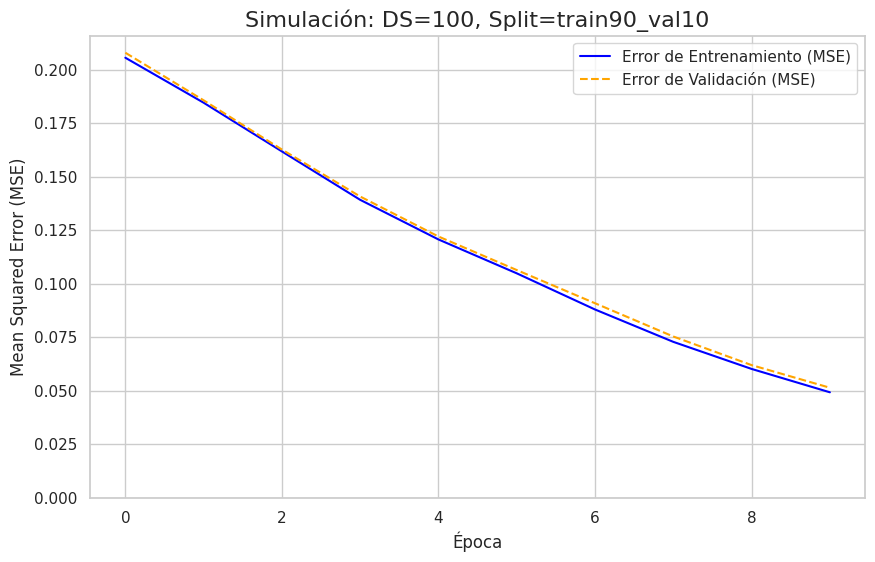


--- Ejecutando: Simulación: DS=100, Split=train80_val20 ---


Entrenando Épocas:   0%|          | 0/10 [00:00<?, ?it/s]

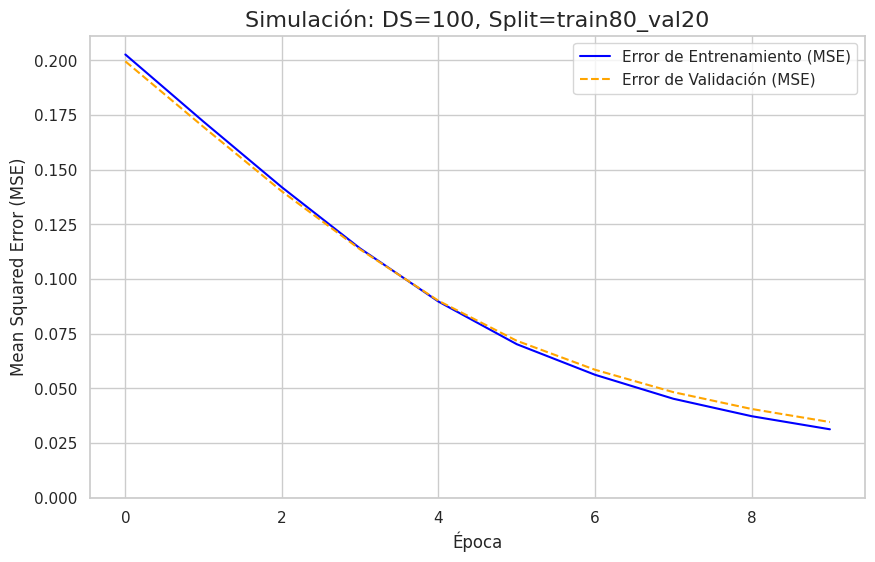


--- Ejecutando: Simulación: DS=100, Split=train70_val30 ---


Entrenando Épocas:   0%|          | 0/10 [00:00<?, ?it/s]

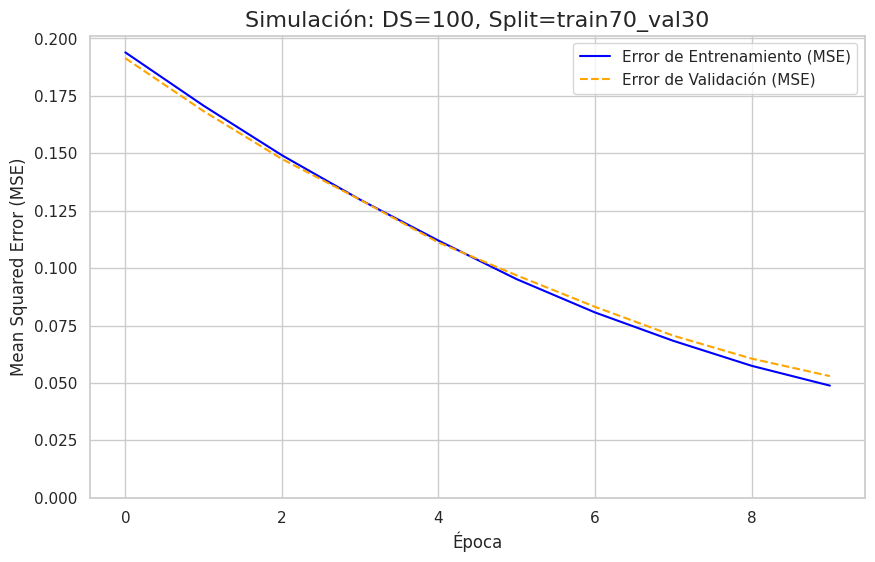


--- Ejecutando: Simulación: DS=500, Split=train90_val10 ---


Entrenando Épocas:   0%|          | 0/10 [00:00<?, ?it/s]

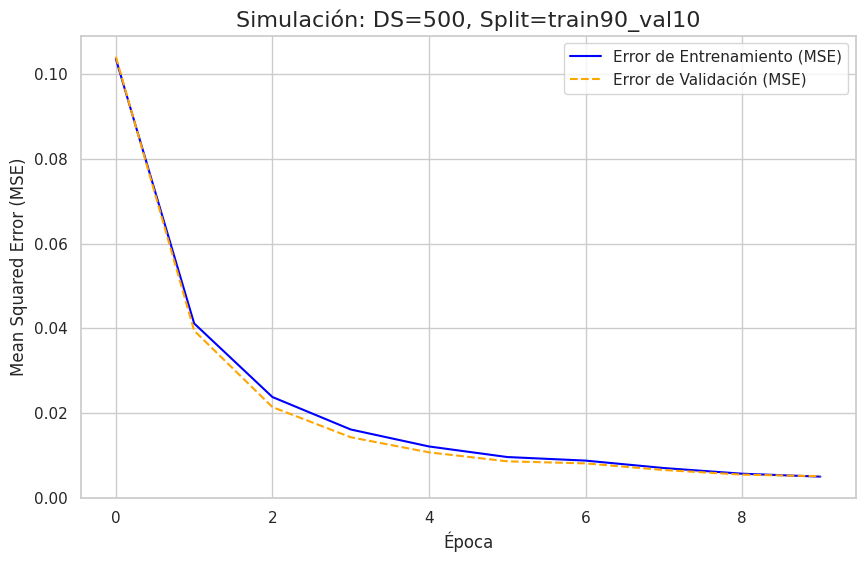


--- Ejecutando: Simulación: DS=500, Split=train80_val20 ---


Entrenando Épocas:   0%|          | 0/10 [00:00<?, ?it/s]

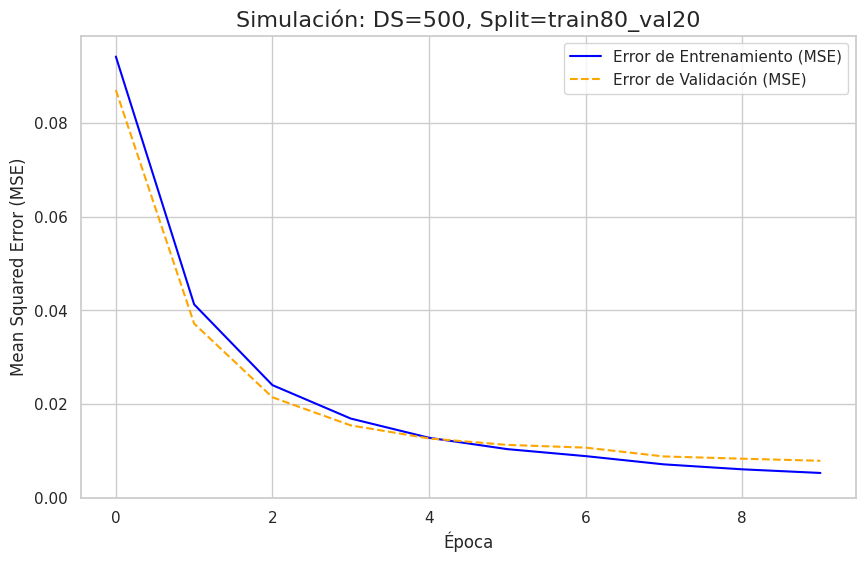


--- Ejecutando: Simulación: DS=500, Split=train70_val30 ---


Entrenando Épocas:   0%|          | 0/10 [00:00<?, ?it/s]

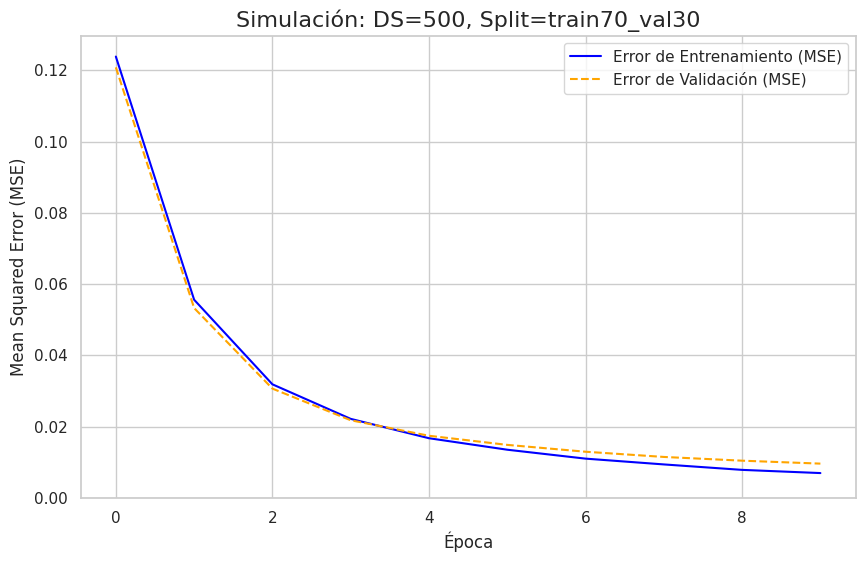


--- Ejecutando: Simulación: DS=1000, Split=train90_val10 ---


Entrenando Épocas:   0%|          | 0/10 [00:00<?, ?it/s]

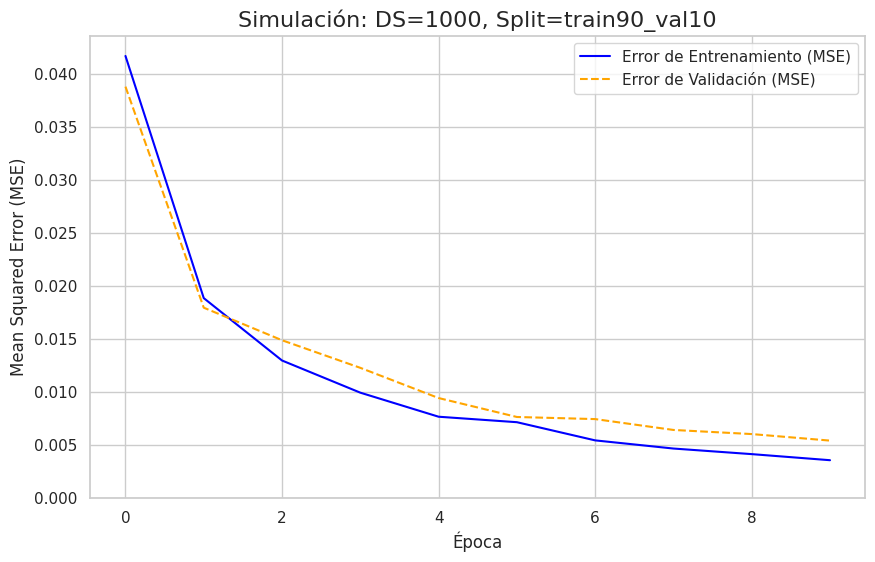


--- Ejecutando: Simulación: DS=1000, Split=train80_val20 ---


Entrenando Épocas:   0%|          | 0/10 [00:00<?, ?it/s]

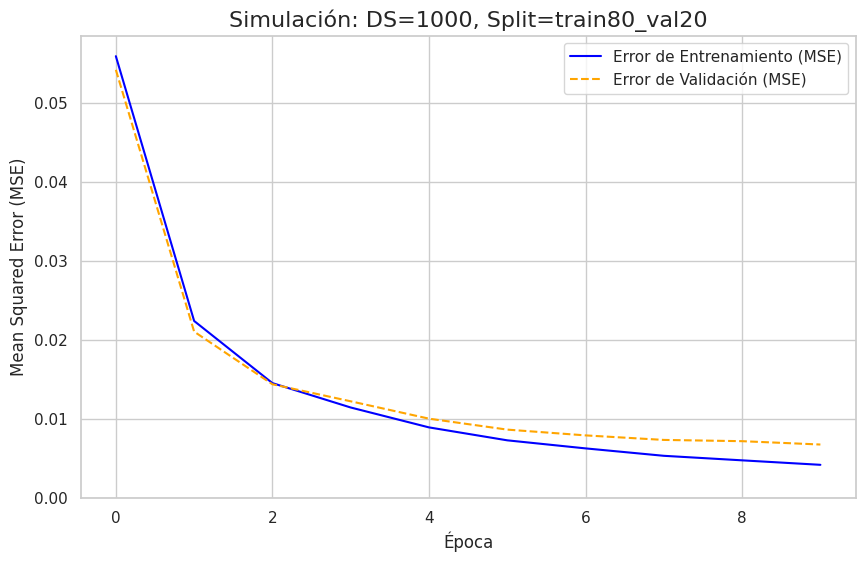


--- Ejecutando: Simulación: DS=1000, Split=train70_val30 ---


Entrenando Épocas:   0%|          | 0/10 [00:00<?, ?it/s]

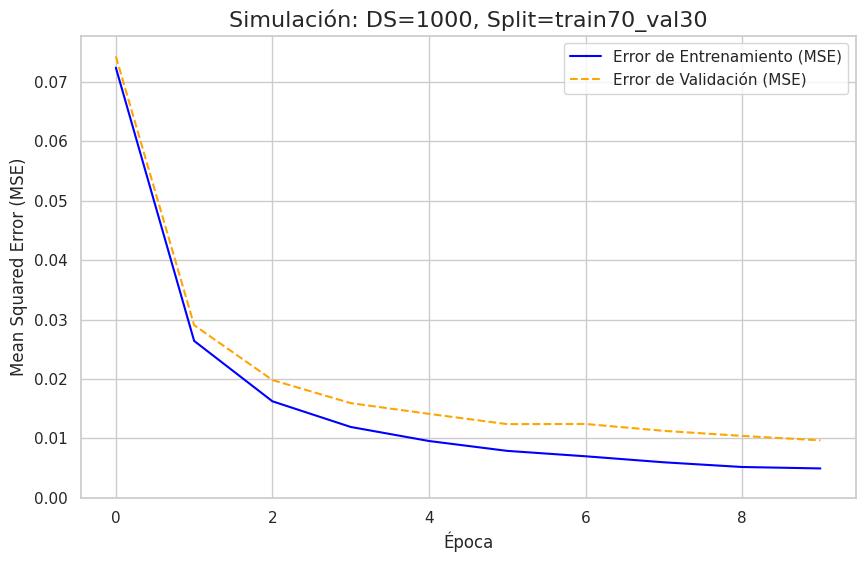


--- SIMULACIÓN DE 9 MODELOS COMPLETADA ---


In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# --- 1. Definir Parámetros Fijos para la Simulación ---

# (Ruta a tu carpeta de datasets en Google Drive)
BASE_PATH = "/content/drive/My Drive/TP_IA_2025/datasets"

# Parámetros fijos de la red (para una comparación justa)
# TP: 1-2 capas ocultas, 5-10 neuronas. Usaremos 1 capa de 10 neuronas.
FIXED_ARCHITECTURE = [100, 10, 3]
FIXED_ACTIVATIONS = [sigmoid, sigmoid]
FIXED_DERIVATIVES = [sigmoid_derivative, sigmoid_derivative]

# Parámetros fijos de entrenamiento
EPOCHS = 10           # N° de épocas por simulación
LEARNING_RATE = 0.01
MOMENTUM = 0.9

# Combinaciones a probar
DATASET_SIZES = [100, 500, 1000]
SPLITS = [
    {'perc': 0.10, 'folder': 'train90_val10'},
    {'perc': 0.20, 'folder': 'train80_val20'},
    {'perc': 0.30, 'folder': 'train70_val30'}
]

# --- 2. Preparar Almacén de Resultados y Encoder ---

# Lista para guardar los resultados finales de cada simulación
simulation_results = []

# Definir el OneHotEncoder una sola vez
encoder = OneHotEncoder(sparse_output=False, categories=[['b', 'd', 'f']])
# Hacemos un 'fit' dummy para que esté listo
encoder.fit(np.array(['b', 'd', 'f']).reshape(-1, 1))

# --- 3. Bucle de Simulación ---

print(f"--- INICIANDO SIMULACIÓN DE 9 MODELOS ---")
print(f"Arquitectura Fija: {FIXED_ARCHITECTURE}")
print(f"Parámetros Fijos: {EPOCHS} épocas, LR={LEARNING_RATE}, M={MOMENTUM}")
print("--------------------------------------------------")

for size in DATASET_SIZES:
    for split in SPLITS:

        folder_name = split['folder']
        dataset_name = f"dataset_{size}"

        sim_title = f"Simulación: DS={size}, Split={folder_name}"
        print(f"\n--- Ejecutando: {sim_title} ---")

        # --- A. Cargar Datos ---
        train_path = f"{BASE_PATH}/{dataset_name}/{folder_name}/train.csv"
        val_path = f"{BASE_PATH}/{dataset_name}/{folder_name}/val.csv"

        X_train, y_train_labels = load_dataset(train_path)
        X_val, y_val_labels = load_dataset(VAL_PATH) # ¡Error común corregido! (usaba VAL_PATH)
        # Corrección:
        X_val, y_val_labels = load_dataset(val_path)


        if X_train is None:
            print(f"Error cargando {train_path}. Saltando simulación.")
            continue

        # --- B. Preparar Datos (One-Hot Encoding) ---
        y_train_oh = encoder.transform(y_train_labels)
        y_val_oh = encoder.transform(y_val_labels)

        # --- C. Inicializar un NUEVO Modelo ---
        # (Es crucial para que cada prueba sea desde cero)
        mlp = MLP(architecture=FIXED_ARCHITECTURE,
                  activations=FIXED_ACTIVATIONS,
                  derivatives=FIXED_DERIVATIVES)

        # --- D. Entrenar ---
        history = mlp.fit(X_train, y_train_oh,
                          X_val, y_val_oh,
                          epochs=EPOCHS,
                          learning_rate=LEARNING_RATE,
                          momentum=MOMENTUM)

        # --- E. Graficar Resultado de esta simulación ---
        plot_error_history(history, title=sim_title)

        # --- F. Guardar Resultados Finales ---
        final_train_mse = history['train_mse'][-1]
        final_val_mse = history['val_mse'][-1]

        simulation_results.append({
            "Dataset": size,
            "Split": folder_name,
            "Train MSE Final": final_train_mse,
            "Val MSE Final": final_val_mse
        })

print("\n--- SIMULACIÓN DE 9 MODELOS COMPLETADA ---")

In [ ]:
import matplotlib.pyplot as plt
import os

def plot_and_save_history(history, title, filename):
    """
    Toma el historial de MSE, genera un gráfico de curva de aprendizaje
    y lo guarda en un archivo.
    """
    try:
        fig, ax = plt.subplots(figsize=(10, 6))

        # Graficar ambas curvas
        ax.plot(history['train_mse'], label='Error de Entrenamiento (MSE)', color='blue')
        ax.plot(history['val_mse'], label='Error de Validación (MSE)', color='orange', linestyle='--')

        ax.set_title(title, fontsize=12) # Título más pequeño para nombres largos
        ax.set_xlabel('Época')
        ax.set_ylabel('Mean Squared Error (MSE)')
        ax.legend()
        ax.grid(True)

        # Usar escala logarítmica si el error es muy alto al inicio,
        # pero para MSE es mejor empezar desde 0.
        ax.set_ylim(bottom=0, top=max(0.5, np.max(history['val_mse'][1:]))) # Ignora el primer MSE si es gigante

        plt.tight_layout()
        plt.savefig(filename)
        plt.close(fig) # ¡MUY IMPORTANTE! Cierra la figura para liberar memoria

    except Exception as e:
        print(f"  [Error al guardar gráfico '{filename}': {e}]")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
import os
import time
from tqdm.notebook import trange # Para barras de progreso

def run_experiment(
    plots_save_path, # Ruta a la carpeta donde guardar los gráficos
    dataset_size, split_info, base_path, encoder,
    architecture, activation_name,
    epochs, learning_rate, momentum
):
    """
    Ejecuta una simulación, reporta el estado Y guarda la curva de aprendizaje.
    """

    # --- 1. Construir info para el log ---
    split_folder = split_info['folder']
    exp_id = (
        f"ds={dataset_size}_split={split_folder}_arch={'-'.join(map(str, architecture))}_"
        f"act={activation_name}_lr={learning_rate}_m={momentum}"
    )

    print(f"\n--- Iniciando Experimento ---\n{exp_id}")

    try:
        # --- 2. Cargar Datos ---
        train_path = f"{base_path}/dataset_{dataset_size}/{split_folder}/train.csv"
        val_path = f"{base_path}/dataset_{dataset_size}/{split_folder}/val.csv"
        X_train, y_train_labels = load_dataset(train_path)
        X_val, y_val_labels = load_dataset(val_path)
        if X_train is None:
            raise FileNotFoundError(f"No se encontraron datos en {train_path} o {val_path}")

        # --- 3. Preparar Datos (One-Hot Encoding) ---
        y_train_oh = encoder.transform(y_train_labels)
        y_val_oh = encoder.transform(y_val_labels)

        # --- 4. Preparar Parámetros de Red ---
        if activation_name == 'sigmoid':
            act_func = sigmoid
            der_func = sigmoid_derivative
        elif activation_name == 'linear':
            act_func = linear
            der_func = linear_derivative
        else:
            raise ValueError(f"Función de activación desconocida: {activation_name}")
        n_layers = len(architecture) - 1
        activations = [act_func] * n_layers
        derivatives = [der_func] * n_layers

        # --- 5. Inicializar y Entrenar ---
        mlp = MLP(architecture=architecture,
                  activations=activations,
                  derivatives=derivatives)
        print(f"Entrenando por {epochs} épocas...")

        history = mlp.fit(X_train, y_train_oh,
                          X_val, y_val_oh,
                          epochs=epochs,
                          learning_rate=learning_rate,
                          momentum=momentum)

        # --- 6. Recopilar Resultados y Estado ---
        final_train_mse = history['train_mse'][-1]
        final_val_mse = history['val_mse'][-1]

        current_status = ""
        if np.isnan(final_val_mse) or np.isinf(final_val_mse):
            current_status = "Diverged (Overflow)"
            print(f"Resultado: {current_status}")
            # (No guardamos el gráfico si divergió)
        else:
            current_status = "success"
            print(f"Resultado: Train MSE={final_train_mse:.6f}, Val MSE={final_val_mse:.6f}")

            try:
                # Crear un nombre de archivo único y seguro
                plot_filename = f"{exp_id}.png"
                # Limpiar caracteres inválidos para un nombre de archivo (aunque exp_id debería ser seguro)
                plot_filename = "".join(c for c in plot_filename if c.isalnum() or c in ('=', '-', '_', '.'))
                full_plot_path = os.path.join(plots_save_path, plot_filename)

                # Llamar a la función de guardado
                plot_and_save_history(history, title=exp_id, filename=full_plot_path)
                print(f"  > Curva de aprendizaje guardada en: {plot_filename}")

            except Exception as e:
                print(f"  [Error al guardar gráfico: {e}]")

        return {
            "exp_id": exp_id,
            "dataset_size": dataset_size,
            "split": split_folder,
            "architecture": str(architecture),
            "activation": activation_name,
            "learning_rate": learning_rate,
            "momentum": momentum,
            "epochs": epochs,
            "Final Train MSE": final_train_mse,
            "Final Val MSE": final_val_mse,
            "status": current_status
        }

    except Exception as e:
        print(f"--- ¡ERROR en el experimento! ---")
        print(f"ID: {exp_id}")
        print(f"Error: {e}")
        return {
            "exp_id": exp_id, "dataset_size": dataset_size, "split": split_folder,
            "architecture": str(architecture), "activation": activation_name,
            "learning_rate": learning_rate, "momentum": momentum, "epochs": epochs,
            "Final Train MSE": np.nan, "Final Val MSE": np.nan,
            "status": f"error: {str(e)}"
        }

In [ ]:
# --- 1. Definición del Espacio de Búsqueda ---

BASE_PATH = "/content/drive/My Drive/TP_IA_2025/datasets"
RESULTS_CSV_PATH = f"{BASE_PATH}/simulation_results.csv"

# Crear una subcarpeta para las 144 curvas de aprendizaje
LEARNING_CURVES_PATH = f"{BASE_PATH}/plots/learning_curves"
os.makedirs(LEARNING_CURVES_PATH, exist_ok=True)
print(f"Las curvas de aprendizaje se guardarán en: {LEARNING_CURVES_PATH}")
# ---

EPOCHS = 20
DATASET_SIZES = [100, 500, 1000]
SPLITS = [
    {'perc': 0.10, 'folder': 'train90_val10'},
    {'perc': 0.20, 'folder': 'train80_val20'},
    {'perc': 0.30, 'folder': 'train70_val30'}
]
ARCHITECTURES = [[100, 10, 3], [100, 10, 5, 3]]
MOMENTUMS = [0.5, 0.9]
LEARNING_RATES = [0.01, 0.1]
ACTIVATION_NAMES = ['sigmoid', 'linear']


encoder = OneHotEncoder(sparse_output=False, categories=[['b', 'd', 'f']])
encoder.fit(np.array(['b', 'd', 'f']).reshape(-1, 1))

all_results = []
completed_exp_ids = set()
if os.path.exists(RESULTS_CSV_PATH):
    print(f"Cargando resultados anteriores desde '{RESULTS_CSV_PATH}'...")
    df_results_prev = pd.read_csv(RESULTS_CSV_PATH)
    all_results = df_results_prev.to_dict('records')
    completed_exp_ids = set(df_results_prev['exp_id'])
    print(f"Se encontraron {len(completed_exp_ids)} simulaciones completadas.")
else:
    print("No se encontró CSV de resultados. Empezando desde cero.")


# --- 3. Bucle Maestro ---
total_sims = len(DATASET_SIZES) * len(SPLITS) * len(ARCHITECTURES) * len(MOMENTUMS) * len(LEARNING_RATES) * len(ACTIVATION_NAMES)
print(f"--- INICIANDO BUCLE MAESTRO: {total_sims} SIMULACIONES TOTALES ---")

sim_counter = 0

for size in DATASET_SIZES:
    for split in SPLITS:
        for arch in ARCHITECTURES:
            for m in MOMENTUMS:
                for lr in LEARNING_RATES:
                    for act_name in ACTIVATION_NAMES:

                        sim_counter += 1
                        current_exp_id = (
                            f"ds={size}_split={split['folder']}_arch={'-'.join(map(str, arch))}_"
                            f"act={act_name}_lr={lr}_m={m}"
                        )

                        if current_exp_id in completed_exp_ids:
                            print(f"({sim_counter}/{total_sims}) Saltando (ya completado): {current_exp_id}")
                            continue

                        print(f"({sim_counter}/{total_sims}) Ejecutando...")
                        start_time = time.time()

                        result = run_experiment(
                            plots_save_path=LEARNING_CURVES_PATH, # <-- ¡NUEVO!
                            dataset_size=size,
                            split_info=split,
                            base_path=BASE_PATH,
                            encoder=encoder,
                            architecture=arch,
                            activation_name=act_name,
                            epochs=EPOCHS,
                            learning_rate=lr,
                            momentum=m
                        )

                        end_time = time.time()
                        print(f"Tiempo de simulación: {end_time - start_time:.2f} segundos.")

                        all_results.append(result)
                        df_results_actual = pd.DataFrame(all_results)
                        df_results_actual.to_csv(RESULTS_CSV_PATH, index=False)
                        completed_exp_ids.add(current_exp_id)

print("\n--- BUCLE MAESTRO COMPLETADO ---")
print(f"Todos los resultados están guardados en: {RESULTS_CSV_PATH}")
print(f"Todas las curvas de aprendizaje están en: {LEARNING_CURVES_PATH}")

In [4]:
# --- Cargar el DataFrame final con todos los resultados ---
results_path = "/content/drive/My Drive/TP_IA_2025/datasets/simulation_results.csv"
try:
    df_final_results = pd.read_csv(results_path)

    print(f"Se cargaron {len(df_final_results)} resultados de simulación.")

    # --- Mostrar los 10 MEJORES modelos (menor error de validación) ---
    print("\n--- MEJORES 10 MODELOS (ordenados por Error de Validación) ---")

    # Seleccionamos las columnas más importantes para ver
    columns_to_show = [
        "Final Val MSE",
        "Final Train MSE",
        "activation",
        "learning_rate",
        "momentum",
        "architecture",
        "dataset_size",
        "split"
    ]

    best_models = df_final_results.sort_values(by="Final Val MSE", ascending=True)
    display(best_models[columns_to_show].head(10))


    # --- Mostrar los 10 PEORES modelos (para ver qué no funcionó) ---
    print("\n--- PEORES 10 MODELOS (Mayor Error de Validación) ---")
    worst_models = df_final_results.sort_values(by="Final Val MSE", ascending=False)
    display(worst_models[columns_to_show].head(10))

except FileNotFoundError:
    print(f"Error: No se encontró el archivo de resultados en {results_path}")
except Exception as e:
    print(f"Ocurrió un error al cargar o analizar los resultados: {e}")

Se cargaron 144 resultados de simulación.

--- MEJORES 10 MODELOS (ordenados por Error de Validación) ---


,Final Val MSE,Final Train MSE,activation,learning_rate,momentum,architecture,dataset_size,split
62,0.000254,0.000130,sigmoid,0.1,0.9,"[100, 10, 5, 3]",500,train90_val10
14,0.001124,0.000852,sigmoid,0.1,0.9,"[100, 10, 5, 3]",100,train90_val10
54,0.001353,0.000095,sigmoid,0.1,0.9,"[100, 10, 3]",500,train90_val10
58,0.001460,0.000871,sigmoid,0.1,0.5,"[100, 10, 5, 3]",500,train90_val10
46,0.001749,0.000984,sigmoid,0.1,0.9,"[100, 10, 5, 3]",100,train70_val30
6,0.001885,0.000387,sigmoid,0.1,0.9,"[100, 10, 3]",100,train90_val10
30,0.002069,0.000929,sigmoid,0.1,0.9,"[100, 10, 5, 3]",100,train80_val20
22,0.002131,0.000428,sigmoid,0.1,0.9,"[100, 10, 3]",100,train80_val20
50,0.002323,0.000721,sigmoid,0.1,0.5,"[100, 10, 3]",500,train90_val10
38,0.002840,0.000510,sigmoid,0.1,0.9,"[100, 10, 3]",100,train70_val30



--- PEORES 10 MODELOS (Mayor Error de Validación) ---


,Final Val MSE,Final Train MSE,activation,learning_rate,momentum,architecture,dataset_size,split
3,inf,inf,linear,0.1,0.5,"[100, 10, 3]",100,train90_val10
7,inf,inf,linear,0.1,0.9,"[100, 10, 3]",100,train90_val10
15,inf,inf,linear,0.1,0.9,"[100, 10, 5, 3]",100,train90_val10
11,inf,inf,linear,0.1,0.5,"[100, 10, 5, 3]",100,train90_val10
75,inf,inf,linear,0.1,0.5,"[100, 10, 5, 3]",500,train80_val20
79,inf,inf,linear,0.1,0.9,"[100, 10, 5, 3]",500,train80_val20
71,inf,inf,linear,0.1,0.9,"[100, 10, 3]",500,train80_val20
43,inf,inf,linear,0.1,0.5,"[100, 10, 5, 3]",100,train70_val30
35,inf,inf,linear,0.1,0.5,"[100, 10, 3]",100,train70_val30
39,inf,inf,linear,0.1,0.9,"[100, 10, 3]",100,train70_val30


Los gráficos se guardarán en: /content/drive/My Drive/TP_IA_2025/datasets/plots
Resultados cargados exitosamente. Total de simulaciones: 144

--- Resumen de Estados de Simulación ---
status
success                108
Diverged (Overflow)     36
Name: count, dtype: int64

Se analizarán 108 simulaciones exitosas.
Generando Gráfico 1: Comparación de Funciones de Activación...


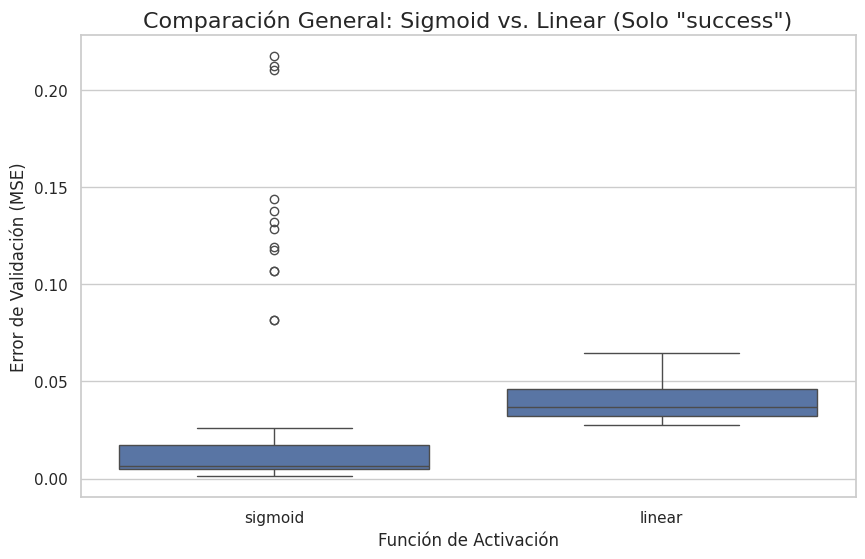

Generando Gráfico 2: Comparación de Arquitecturas...


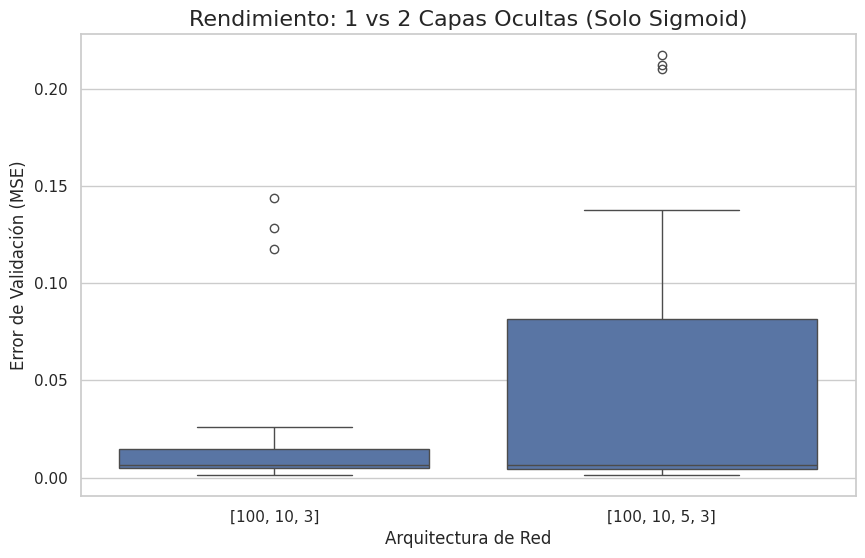

Generando Gráfico 3: Comparación de Tasa de Aprendizaje...


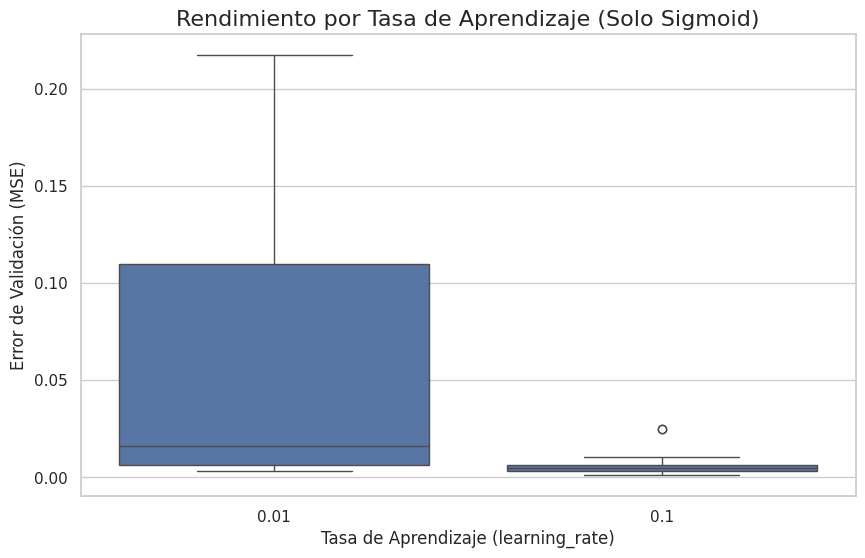

Generando Gráfico 4: Comparación de Término Momento...


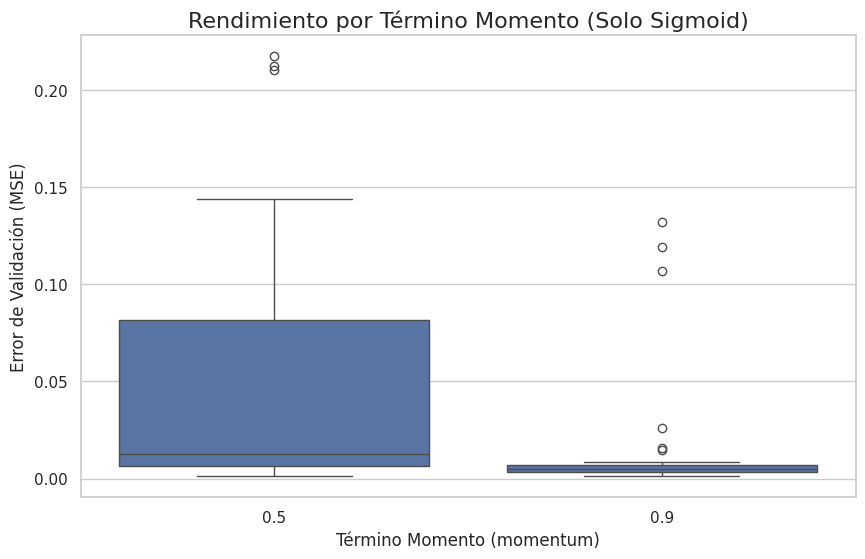

Generando Gráfico 5: Comparación por Tamaño de Dataset...


/tmp/ipython-input-2798163167.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sigmoid, x='dataset_size', y='Final Val MSE', estimator=np.mean, palette='Blues_d')


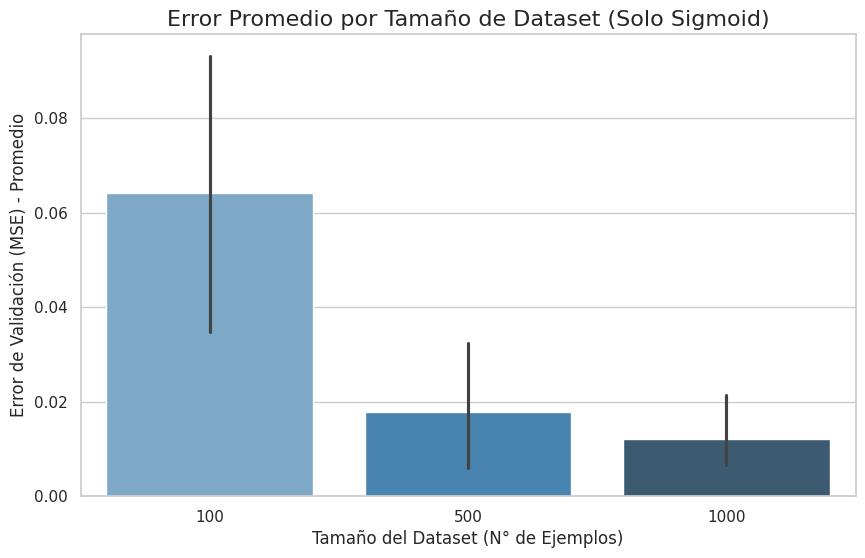

Generando Gráfico 6: Top 10 Mejores Combinaciones...


/tmp/ipython-input-2798163167.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top10, y='label', x='Final Val MSE', orient='h', palette='viridis')


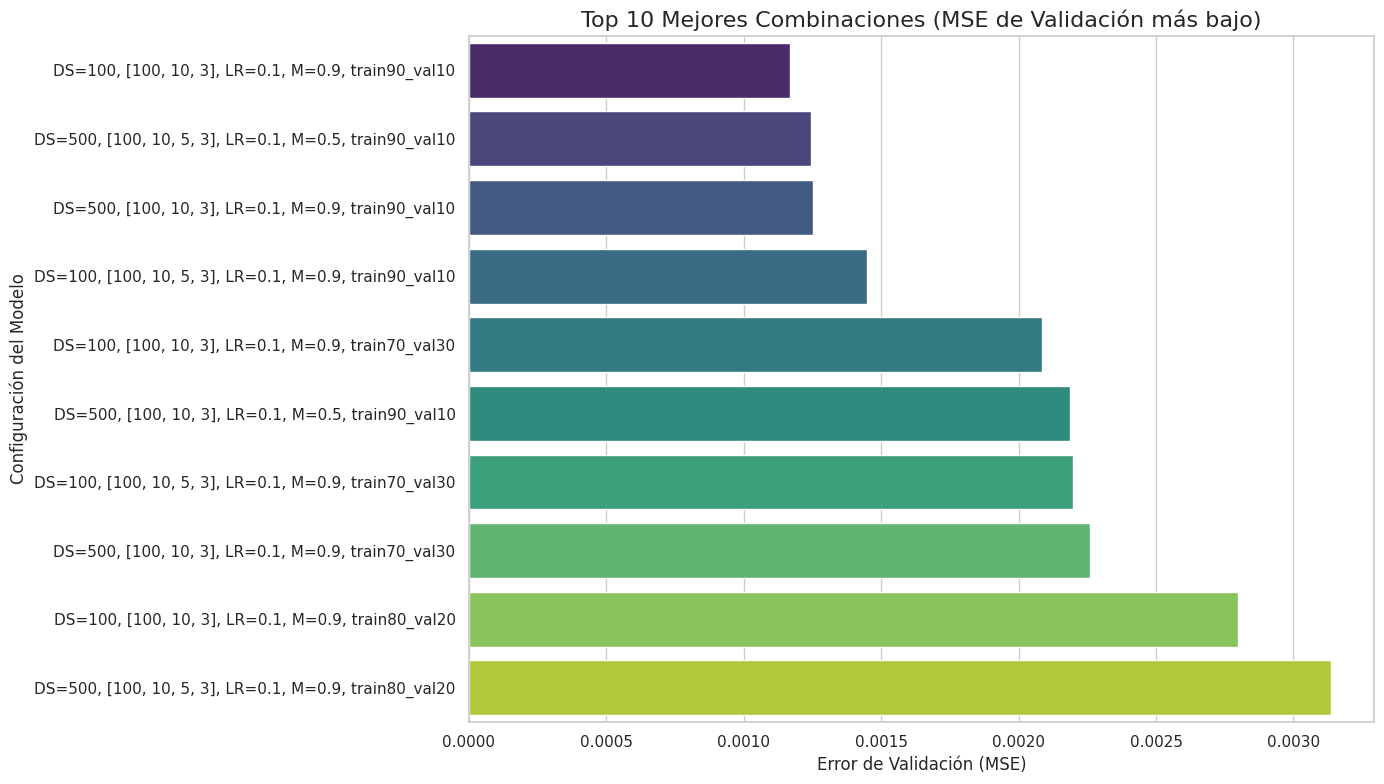


--- ¡Análisis gráfico completado! ---


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. Cargar el Archivo de Resultados ---
results_path = "/content/drive/My Drive/TP_IA_2025/datasets/simulation_results.csv"
plots_save_path = "/content/drive/My Drive/TP_IA_2025/datasets/plots"

# Crear la carpeta de gráficos si no existe
os.makedirs(plots_save_path, exist_ok=True)
print(f"Los gráficos se guardarán en: {plots_save_path}")

try:
    df_full_results = pd.read_csv(results_path)
    print(f"Resultados cargados exitosamente. Total de simulaciones: {len(df_full_results)}")
except FileNotFoundError:
    print(f"ERROR: No se encontró el archivo de resultados en '{results_path}'")
    print("Por favor, asegúrate de que el 'Bucle Maestro' se haya ejecutado y guardado el archivo.")

# --- 2. Preparar los Datos para Graficar ---

# Imprimir un resumen de cuántas simulaciones fallaron
print("\n--- Resumen de Estados de Simulación ---")
print(df_full_results['status'].value_counts())

# Filtraremos los experimentos que DIVERGIERON (overflow),
# ya que un MSE de 'inf' arruinaría la escala de todos los gráficos.
# Nos enfocaremos solo en los que completaron 'success'.
df_clean = df_full_results[df_full_results['status'] == 'success'].copy()
print(f"\nSe analizarán {len(df_clean)} simulaciones exitosas.")

# --- 3. Gráficos de General a Específico ---

sns.set(style="whitegrid")

# --- Gráfico 1 (General): ¿Qué Función de Activación funcionó? ---
print("Generando Gráfico 1: Comparación de Funciones de Activación...")
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='activation', y='Final Val MSE')
plt.title('Comparación General: Sigmoid vs. Linear (Solo "success")', fontsize=16)
plt.ylabel('Error de Validación (MSE)')
plt.xlabel('Función de Activación')
plt.savefig(os.path.join(plots_save_path, 'plot_1_activation.png'))
plt.show()

# --- Filtro: A partir de ahora, nos enfocamos en 'sigmoid' ---
# Como 'linear' es inestable y funciona mal, lo filtramos
# para analizar los otros hiperparámetros de forma justa.
df_sigmoid = df_clean[df_clean['activation'] == 'sigmoid'].copy()

# --- Gráfico 2 (Específico): 1 vs 2 Capas Ocultas---
print("Generando Gráfico 2: Comparación de Arquitecturas...")
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_sigmoid, x='architecture', y='Final Val MSE')
plt.title('Rendimiento: 1 vs 2 Capas Ocultas (Solo Sigmoid)', fontsize=16)
plt.ylabel('Error de Validación (MSE)')
plt.xlabel('Arquitectura de Red')
plt.savefig(os.path.join(plots_save_path, 'plot_2_layers.png'))
plt.show()

# --- Gráfico 3 (Específico): Tasa de Aprendizaje ---
print("Generando Gráfico 3: Comparación de Tasa de Aprendizaje...")
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_sigmoid, x='learning_rate', y='Final Val MSE')
plt.title('Rendimiento por Tasa de Aprendizaje (Solo Sigmoid)', fontsize=16)
plt.ylabel('Error de Validación (MSE)')
plt.xlabel('Tasa de Aprendizaje (learning_rate)')
plt.savefig(os.path.join(plots_save_path, 'plot_3_learning_rate.png'))
plt.show()

# --- Gráfico 4 (Específico): Término Momento ---
print("Generando Gráfico 4: Comparación de Término Momento...")
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_sigmoid, x='momentum', y='Final Val MSE')
plt.title('Rendimiento por Término Momento (Solo Sigmoid)', fontsize=16)
plt.ylabel('Error de Validación (MSE)')
plt.xlabel('Término Momento (momentum)')
plt.savefig(os.path.join(plots_save_path, 'plot_4_momentum.png'))
plt.show()

# --- Gráfico 5 (Específico): Tamaño del Dataset ---
print("Generando Gráfico 5: Comparación por Tamaño de Dataset...")
plt.figure(figsize=(10, 6))
# Usamos barplot para ver el promedio (mean)
sns.barplot(data=df_sigmoid, x='dataset_size', y='Final Val MSE', estimator=np.mean, palette='Blues_d')
plt.title('Error Promedio por Tamaño de Dataset (Solo Sigmoid)', fontsize=16)
plt.ylabel('Error de Validación (MSE) - Promedio')
plt.xlabel('Tamaño del Dataset (N° de Ejemplos)')
plt.savefig(os.path.join(plots_save_path, 'plot_5_dataset_size.png'))
plt.show()

# --- Gráfico 6 (Final): Las 10 Mejores Combinaciones ---
print("Generando Gráfico 6: Top 10 Mejores Combinaciones...")
df_top10 = df_sigmoid.sort_values(by='Final Val MSE').head(10)

# Crear una etiqueta legible para el eje Y
df_top10['label'] = (
    "DS=" + df_top10['dataset_size'].astype(str) +
    ", " + df_top10['architecture'] +
    ", LR=" + df_top10['learning_rate'].astype(str) +
    ", M=" + df_top10['momentum'].astype(str) +
    ", " + df_top10['split']
)

plt.figure(figsize=(14, 8)) # Gráfico más grande
sns.barplot(data=df_top10, y='label', x='Final Val MSE', orient='h', palette='viridis')
plt.title('Top 10 Mejores Combinaciones (MSE de Validación más bajo)', fontsize=16)
plt.xlabel('Error de Validación (MSE)')
plt.ylabel('Configuración del Modelo')
plt.tight_layout() # Ajustar para que las etiquetas no se corten
plt.savefig(os.path.join(plots_save_path, 'plot_6_top10.png'))
plt.show()

print("\n--- ¡Análisis gráfico completado! ---")

Datos de 72 simulaciones 'sigmoid' cargados.
Generando Gráfico 7: Heatmaps de Hiperparámetros...


/tmp/ipython-input-2796397623.py:37: FutureWarning: The provided callable <function mean at 0x7ec5363d4220> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_1_layer = df_1_layer.pivot_table(
/tmp/ipython-input-2796397623.py:40: FutureWarning: The provided callable <function mean at 0x7ec5363d4220> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_2_layers = df_2_layers.pivot_table(


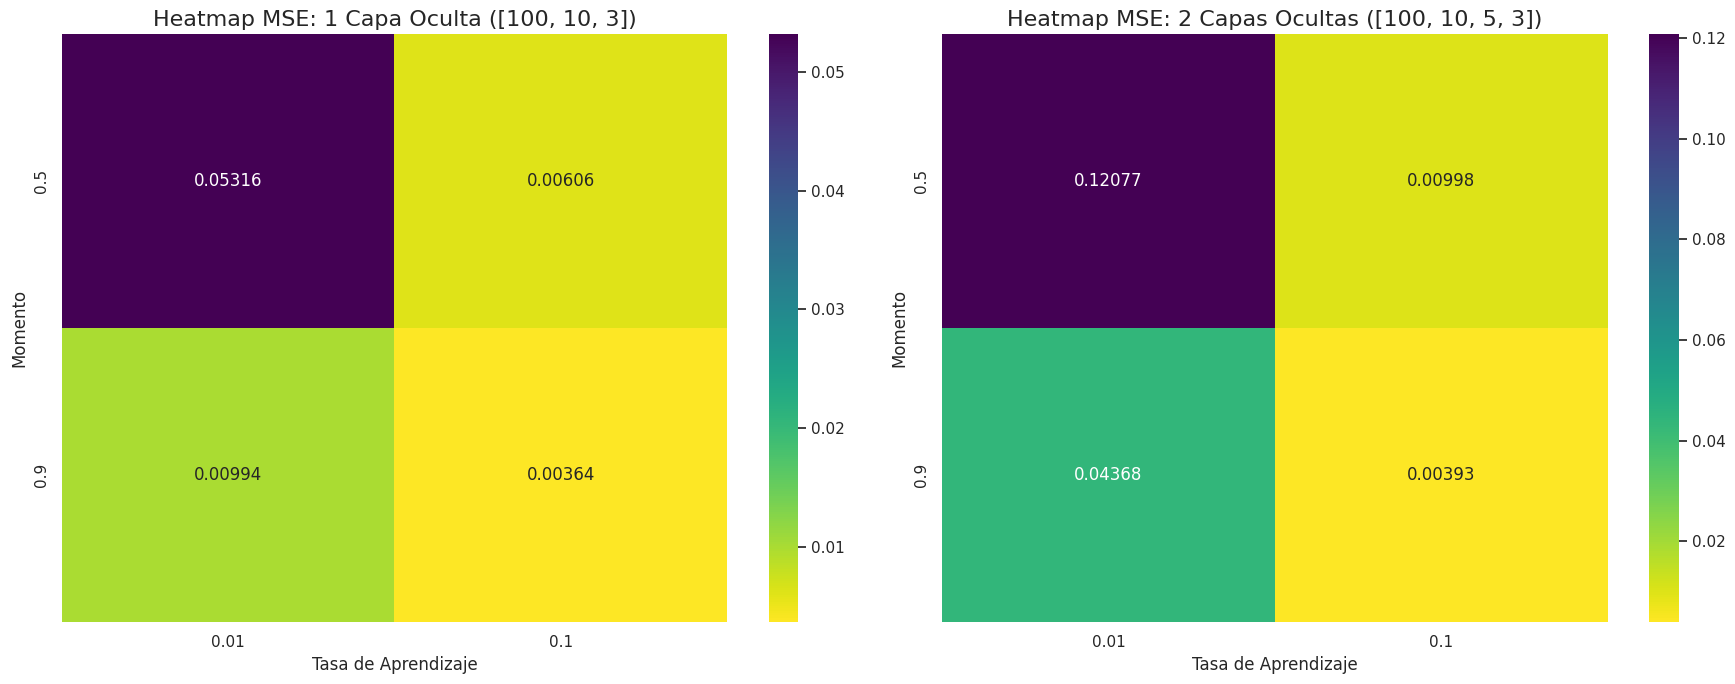

Generando Gráfico 8: Interacción Arquitectura vs. Tamaño Dataset...


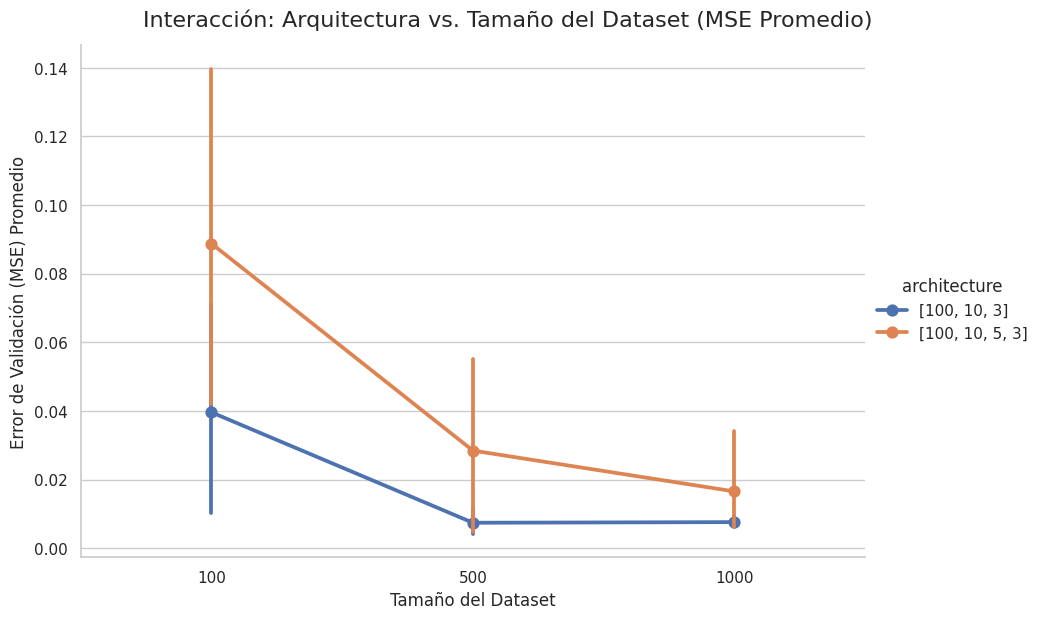

Generando Gráfico 9: Matriz de Confusión del Mejor Modelo...
--- Parámetros del Mejor Modelo ---
  MSE de Val: 0.001167
  Arquitectura: [100, 10, 3]
  Dataset: 100 (train90_val10)
  LR: 0.1, Momento: 0.9

Re-entrenando el mejor modelo para generar la matriz...


Entrenando Épocas:   0%|          | 0/20 [00:00<?, ?it/s]

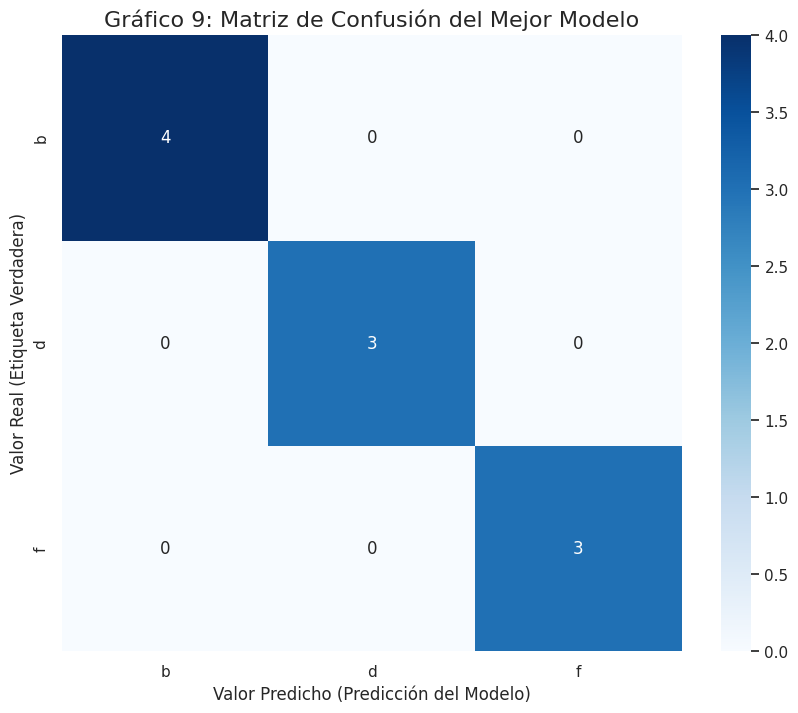


--- ¡Análisis gráfico adicional completado! ---


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import ast
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import OneHotEncoder

# --- 1. Cargar y Preparar Datos---
results_path = "/content/drive/My Drive/TP_IA_2025/datasets/simulation_results.csv"
plots_save_path = "/content/drive/My Drive/TP_IA_2025/datasets/plots"
BASE_PATH = "/content/drive/My Drive/TP_IA_2025/datasets"

try:
    df_full_results = pd.read_csv(results_path)
except FileNotFoundError:
    print(f"ERROR: No se encontró el archivo de resultados en '{results_path}'")

df_sigmoid = df_full_results[
    (df_full_results['status'] == 'success') &
    (df_full_results['activation'] == 'sigmoid')
].copy()

print(f"Datos de {len(df_sigmoid)} simulaciones 'sigmoid' cargados.")


# --- Gráfico 7: Heatmap de Hiperparámetros (LR vs. Momento) ---
print("Generando Gráfico 7: Heatmaps de Hiperparámetros...")
# Queremos ver el MSE promedio para cada combinación de LR/Momentum
# Lo haremos por separado para cada arquitectura

# Pivotear los datos para el heatmap
df_1_layer = df_sigmoid[df_sigmoid['architecture'] == '[100, 10, 3]']
df_2_layers = df_sigmoid[df_sigmoid['architecture'] == '[100, 10, 5, 3]']

pivot_1_layer = df_1_layer.pivot_table(
    values='Final Val MSE', index='momentum', columns='learning_rate', aggfunc=np.mean
)
pivot_2_layers = df_2_layers.pivot_table(
    values='Final Val MSE', index='momentum', columns='learning_rate', aggfunc=np.mean
)

# Crear 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(pivot_1_layer, annot=True, fmt=".5f", cmap="viridis_r", ax=ax1)
ax1.set_title('Heatmap MSE: 1 Capa Oculta ([100, 10, 3])', fontsize=16)
ax1.set_xlabel('Tasa de Aprendizaje')
ax1.set_ylabel('Momento')

sns.heatmap(pivot_2_layers, annot=True, fmt=".5f", cmap="viridis_r", ax=ax2)
ax2.set_title('Heatmap MSE: 2 Capas Ocultas ([100, 10, 5, 3])', fontsize=16)
ax2.set_xlabel('Tasa de Aprendizaje')
ax2.set_ylabel('Momento')

plt.tight_layout()
plt.savefig(os.path.join(plots_save_path, 'plot_7_heatmaps_lr_momentum.png'))
plt.show()


# --- Gráfico 8: Interacción de Arquitectura y Tamaño del Dataset ---
print("Generando Gráfico 8: Interacción Arquitectura vs. Tamaño Dataset...")
# Usamos catplot (kind='point') para ver la tendencia promedio
g = sns.catplot(
    data=df_sigmoid,
    x='dataset_size',
    y='Final Val MSE',
    hue='architecture',
    kind='point',
    height=6,
    aspect=1.5
)
g.fig.suptitle('Interacción: Arquitectura vs. Tamaño del Dataset (MSE Promedio)', y=1.03, fontsize=16)
g.set_axis_labels('Tamaño del Dataset', 'Error de Validación (MSE) Promedio')
plt.savefig(os.path.join(plots_save_path, 'plot_8_interaction_arch_size.png'))
plt.show()


# --- Gráfico 9: Matriz de Confusión (para el *Mejor* Modelo) ---
print("Generando Gráfico 9: Matriz de Confusión del Mejor Modelo...")

# 1. Encontrar el mejor modelo de todos
best_model_params = df_sigmoid.sort_values(by='Final Val MSE').iloc[0]

print("--- Parámetros del Mejor Modelo ---")
print(f"  MSE de Val: {best_model_params['Final Val MSE']:.6f}")
print(f"  Arquitectura: {best_model_params['architecture']}")
print(f"  Dataset: {best_model_params['dataset_size']} ({best_model_params['split']})")
print(f"  LR: {best_model_params['learning_rate']}, Momento: {best_model_params['momentum']}")

try:
    # 2. Re-crear los parámetros para entrenar

    # Cargar datos
    ds_size = best_model_params['dataset_size']
    ds_split = best_model_params['split']
    train_path = f"{BASE_PATH}/dataset_{ds_size}/{ds_split}/train.csv"
    val_path = f"{BASE_PATH}/dataset_{ds_size}/{ds_split}/val.csv"
    X_train, y_train_labels = load_dataset(train_path)
    X_val, y_val_labels = load_dataset(val_path)

    # Preparar Encoder
    encoder = OneHotEncoder(sparse_output=False, categories=[['b', 'd', 'f']])
    y_train_oh = encoder.fit_transform(y_train_labels)
    y_val_oh = encoder.transform(y_val_labels)

    # Preparar parámetros de red
    # Usamos 'ast.literal_eval' para convertir el string "[100, 10, 3]" en lista [100, 10, 3]
    best_arch = ast.literal_eval(best_model_params['architecture'])
    n_layers = len(best_arch) - 1
    best_acts = [sigmoid] * n_layers
    best_ders = [sigmoid_derivative] * n_layers

    # 3. Re-entrenar el mejor modelo
    print(f"\nRe-entrenando el mejor modelo para generar la matriz...")
    best_mlp = MLP(
        architecture=best_arch,
        activations=best_acts,
        derivatives=best_ders
    )

    # Usar las épocas y parámetros óptimos
    best_mlp.fit(
        X_train, y_train_oh,
        X_val, y_val_oh,
        epochs=best_model_params['epochs'],
        learning_rate=best_model_params['learning_rate'],
        momentum=best_model_params['momentum']
    )

    # 4. Obtener predicciones en el set de validación
    preds_raw = best_mlp.predict(X_val, batch_mode=True)

    # Convertir probabilidades (raw) a la clase predicha (índice 0, 1, o 2)
    y_pred_indices = np.argmax(preds_raw, axis=1)

    # Convertir One-Hot (true) a la clase real (índice 0, 1, o 2)
    y_true_indices = np.argmax(y_val_oh, axis=1)

    # 5. Calcular la Matriz de Confusión
    cm = confusion_matrix(y_true_indices, y_pred_indices)

    # 6. Graficar la Matriz de Confusión
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,     # Mostrar los números dentro de las celdas
        fmt='d',        # Formato de número (entero)
        cmap='Blues',   # Paleta de colores
        xticklabels=encoder.categories_[0], # Etiquetas 'b', 'd', 'f'
        yticklabels=encoder.categories_[0]
    )
    plt.title('Gráfico 9: Matriz de Confusión del Mejor Modelo', fontsize=16)
    plt.ylabel('Valor Real (Etiqueta Verdadera)')
    plt.xlabel('Valor Predicho (Predicción del Modelo)')
    plt.savefig(os.path.join(plots_save_path, 'plot_9_confusion_matrix.png'))
    plt.show()

except Exception as e:
    print(f"\n--- ERROR al generar la Matriz de Confusión ---")
    print(f"Ocurrió un error: {e}")
    print("Esto puede pasar si el script no puede encontrar la clase MLP o las funciones de carga.")

print("\n--- ¡Análisis gráfico adicional completado! ---")